In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import PercentFormatter


In [3]:
#baseline 5.0
#y10name='BrownDwarfs/baseline_v5_0_0_10yrs_RL2parallax_HEAL.npz'
#y02name='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
#y10nameT2='BrownDwarfs/baseline_v5_0_0_10yrs_RT2parallax_HEAL.npz'
#y02nameT2='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RT2parallax_night_lt_730_HEAL.npz'
# baseline 5.3 with tons of engineering time
y10name='BrownDwarfs/baseline_v5_3_0_10yrs_RL2parallax_HEAL.npz'
y02name='BrownDwarfsYear2/baseline_v5_3_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
y10nameT2='BrownDwarfs/baseline_v5_3_0_10yrs_RT2parallax_HEAL.npz'
y02nameT2='BrownDwarfsYear2/baseline_v5_3_0_10yrs_RT2parallax_night_lt_730_HEAL.npz'


In [4]:
yy10=np.load(y10name)
yy02 = np.load(y02name)
#
yy10T2=np.load(y10nameT2)
yy02T2 = np.load(y02nameT2)

In [5]:
print(yy10.files)

['header', 'metric_values', 'mask', 'fill', 'slicer_init', 'slicer_name', 'slice_points', 'slicer_n_slice', 'slicer_shape']


In [6]:
yy10['metric_values']

array([0.00000000e+000, 9.10463678e-318, 0.00000000e+000, ...,
       4.91388986e+001, 4.79256354e+001, 4.68782095e+001], shape=(49152,))

In [7]:
#compute factor to normalize
norm = yy10['metric_values'].shape[0] 
# divide by 100 to get percentages later on
# not used
print(norm)
#this is 12 * 64**2

49152


In [8]:
bins = np.linspace(0, 200, 41)
bins2 = np.linspace(0, 220, 221)
bins

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
       165., 170., 175., 180., 185., 190., 195., 200.])

In [9]:
w10=np.ones(len(yy10['metric_values'])) / len(yy10['metric_values'])
w02=np.ones(len(yy02['metric_values'])) / len(yy02['metric_values'])
print(w10)
print(w02)
#note these are expected to be the same!

[2.03450521e-05 2.03450521e-05 2.03450521e-05 ... 2.03450521e-05
 2.03450521e-05 2.03450521e-05]
[2.03450521e-05 2.03450521e-05 2.03450521e-05 ... 2.03450521e-05
 2.03450521e-05 2.03450521e-05]


In [10]:
wfd_nominal = 18000.0/41253



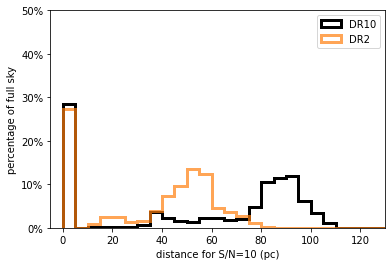

In [11]:
#plt.hist(yy10['metric_values'], histtype='stepfilled', bins=30, alpha=0.3, linewidth=4, label='DR10', color='blue',
#         edgecolor='k', weights=w10)
plt.hist(yy10['metric_values'], histtype='step', bins=bins, alpha=1, linewidth=3, color='k', label='DR10',weights=w10)
plt.hist(yy02['metric_values'], histtype='step', bins=bins, alpha=0.7, linewidth=3, label='DR2', color='C1', weights=w02)
plt.xlim(-5,130)
plt.ylim(0,0.5)  #note this is the original units, fractions
plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('distance for S/N=10 (pc)')
plt.ylabel('percentage of full sky')
plt.savefig('test.png')

In [12]:
import healpy as hp


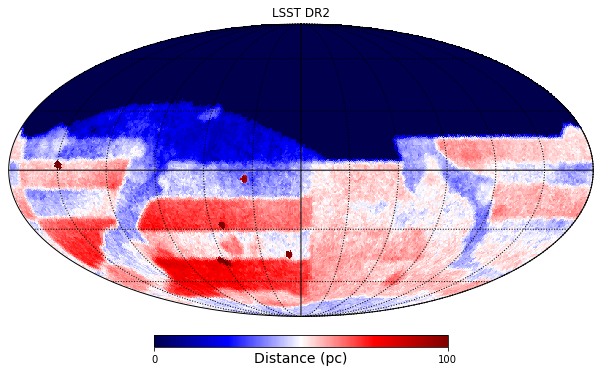

In [13]:
# same color map as Rubin Observaory uses: cmap="viridis"
#  can also try a diverging color map like seismic
hp.mollview(yy02['metric_values'], title="LSST DR2", unit="Distance (pc)", cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
plt.show()

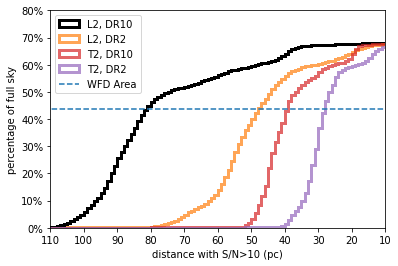

In [14]:
#plt.hist(yy10['metric_values'], histtype='stepfilled', bins=30, alpha=0.3, linewidth=4, label='DR10', color='blue',
#         edgecolor='k', weights=w10)
plt.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, color='k', label='L2, DR10', cumulative=-1, weights=w10)
plt.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='L2, DR2', color='C1', cumulative=-1, weights=w02)
plt.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, color='C3', label='T2, DR10', cumulative=-1, weights=w10)
plt.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='T2, DR2', color='C4', cumulative=-1, weights=w02)
plt.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Area')
plt.xlim(110,10)
plt.ylim(0,0.8)  #note this is the original units, fractions
plt.legend(loc='upper left')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('distance with S/N>10 (pc)')
plt.ylabel('percentage of full sky')
plt.xticks(np.arange(10, 111, step=10))
plt.savefig('test_cumulative.pdf')

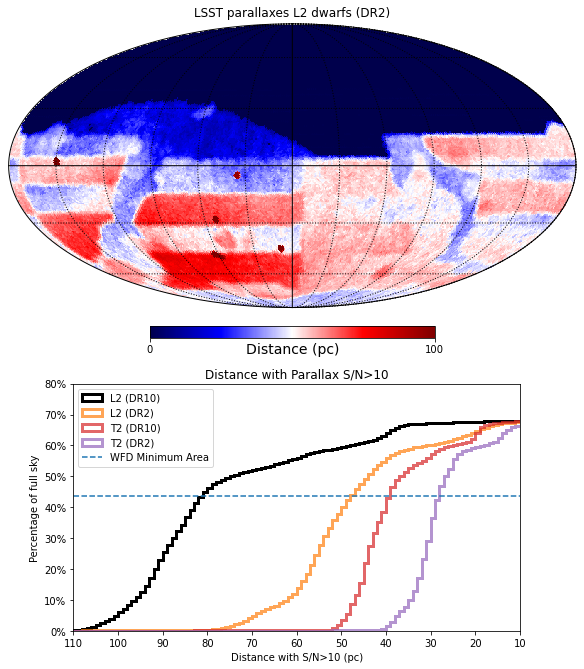

In [15]:
fig = plt.figure(figsize=(8, 10))
hp.mollview(yy02['metric_values'], title="LSST parallaxes L2 dwarfs (DR2)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (DR10)',weights=w10)
ax_hist.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (DR2)', color='C1', weights=w02)
ax_hist.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR10)', color='C3', weights=w02)
ax_hist.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Minimum Area')
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.8)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.legend(loc='upper left')
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
plt.savefig('plot-figure1.png')

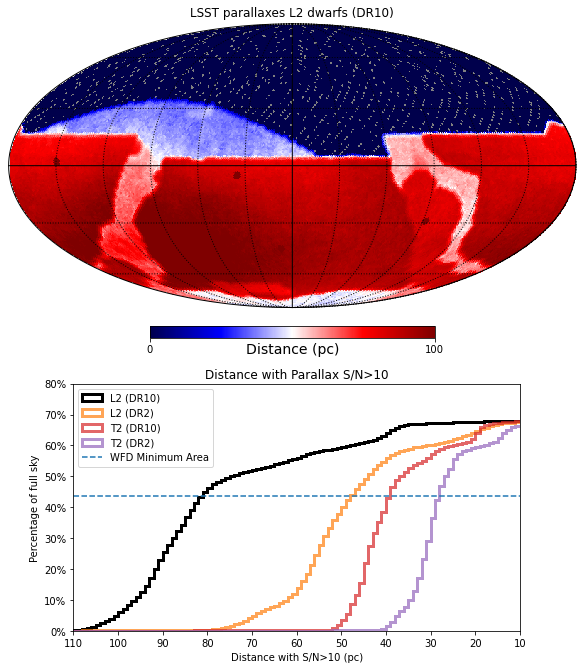

In [16]:
fig = plt.figure(figsize=(8, 10))
hp.mollview(yy10['metric_values'], title="LSST parallaxes L2 dwarfs (DR10)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (DR10)',weights=w10)
ax_hist.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (DR2)', color='C1', weights=w02)
ax_hist.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR10)', color='C3', weights=w02)
ax_hist.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Minimum Area')
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.8)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.legend(loc='upper left')
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))